<a href="https://colab.research.google.com/github/gustavomachin/PortfolioOptimization_Python/blob/master/GenIA_para_Finanzas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Paso 1: Importar librerías**

Este paso importa todas las bibliotecas necesarias para el análisis de la cartera, como `yfinance` para datos financieros, `numpy` y `pandas` para manipulación de datos, `scipy.optimize` para optimización, `matplotlib.pyplot` para gráficos y `google.colab.files` para posibles descargas.

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from google.colab import files

### **Paso 2: Descargar Precios Históricos y Definir Parámetros**

Aquí, definimos los tickers de los activos que componen la cartera (panel Merval argentino). Usaremos `yfinance` para descargar los precios de cierre ajustados (Adjusted Close) de los últimos 2 años para cada activo. La tasa libre de riesgo se establece en 0, como se especificó.

In [ ]:
# Tickers de los activos del panel Merval
assets = ['GGAL.BA', 'YPFD.BA', 'PAMP.BA', 'BMA.BA', 'CEPU.BA']

# Tasa libre de riesgo
risk_free_rate = 0

# Descargar datos históricos (últimos 2 años)
data = yf.download(assets, period='2y')

# Filtrar solo los precios de cierre (Close)
prices = data['Close'].dropna()

# Mostrar los primeros 5 rows de los precios de cierre
print("Precios de cierre:")
display(prices.head())

/tmp/ipykernel_662/3027909201.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(assets, period='2y')
[*********************100%***********************]  5 of 5 completed

Precios de cierre:


Ticker,BMA.BA,CEPU.BA,GGAL.BA,PAMP.BA,YPFD.BA
Date,,,,,
2024-04-22,4761.260254,1084.449951,2875.109131,1961.250000,22244.750000
2024-04-23,4628.650391,1075.349976,2818.190430,1912.500000,22072.500000
2024-04-24,4374.386719,1043.099976,2699.657959,1839.500000,21456.150391
2024-04-25,4487.030273,1069.300049,2803.093750,1900.900024,21998.150391
2024-04-26,4696.456543,1096.000000,2907.364746,1913.349976,22956.650391


### **Paso 3: Calcular Rendimientos Logarítmicos, Matriz de Covarianza y Matriz de Correlación**

Este paso calcula los rendimientos logarítmicos diarios de cada activo, que son preferidos para cálculos de cartera. Luego, a partir de estos rendimientos, se estiman los rendimientos anuales esperados, la matriz de covarianzas anual (que mide cómo los rendimientos de los activos se mueven juntos) y la matriz de correlaciones anual (que indica la fuerza y dirección de la relación lineal entre los rendimientos de los activos).

In [ ]:
# Calcular rendimientos logarítmicos diarios
log_returns = np.log(prices / prices.shift(1)).dropna()

# Número de días de trading en un año
N_TRADING_DAYS = 252

# Calcular rendimientos anuales esperados (media de los rendimientos logarítmicos diarios anualizada)
expected_returns = log_returns.mean() * N_TRADING_DAYS

# Calcular la matriz de covarianzas anual
cov_matrix = log_returns.cov() * N_TRADING_DAYS

# Calcular la matriz de correlaciones
corr_matrix = log_returns.corr()

print("Rendimientos esperados anuales:")
display(expected_returns)

print("Matriz de Covarianzas anual:")
display(cov_matrix)

print("Matriz de Correlaciones:")
display(corr_matrix)

Rendimientos esperados anuales:


,0
Ticker,
BMA.BA,0.467437
CEPU.BA,0.380191
GGAL.BA,0.449232
PAMP.BA,0.457993
YPFD.BA,0.511710


Matriz de Covarianzas anual:


Ticker,BMA.BA,CEPU.BA,GGAL.BA,PAMP.BA,YPFD.BA
Ticker,,,,,
BMA.BA,0.377580,0.237635,0.314938,0.208059,0.196632
CEPU.BA,0.237635,0.280157,0.224482,0.183676,0.174792
GGAL.BA,0.314938,0.224482,0.312493,0.190258,0.182428
PAMP.BA,0.208059,0.183676,0.190258,0.195682,0.165901
YPFD.BA,0.196632,0.174792,0.182428,0.165901,0.211132


Matriz de Correlaciones:


Ticker,BMA.BA,CEPU.BA,GGAL.BA,PAMP.BA,YPFD.BA
Ticker,,,,,
BMA.BA,1.000000,0.730644,0.916854,0.765433,0.696423
CEPU.BA,0.730644,1.000000,0.758684,0.784470,0.718696
GGAL.BA,0.916854,0.758684,1.000000,0.769391,0.710222
PAMP.BA,0.765433,0.784470,0.769391,1.000000,0.816199
YPFD.BA,0.696423,0.718696,0.710222,0.816199,1.000000


### **Paso 4: Calcular Rendimiento y Riesgo de una Cartera Equiponderada**

Se define una cartera equiponderada, donde cada activo tiene el mismo peso (20% en este caso). Luego, se calcula el rendimiento esperado y la volatilidad (riesgo) de esta cartera utilizando los rendimientos esperados y la matriz de covarianzas anuales.

In [ ]:
# Número de activos
num_assets = len(assets)

# Pesos de la cartera equiponderada (20% cada uno)
equally_weighted_weights = np.array([1./num_assets] * num_assets)

# Calcular el rendimiento de la cartera equiponderada
equally_weighted_portfolio_return = np.sum(equally_weighted_weights * expected_returns)

# Calcular la volatilidad de la cartera equiponderada
equally_weighted_portfolio_volatility = np.sqrt(np.dot(equally_weighted_weights.T, np.dot(cov_matrix, equally_weighted_weights)))

print(f"Rendimiento de la Cartera Equiponderada: {equally_weighted_portfolio_return:.4f}")
print(f"Volatilidad de la Cartera Equiponderada: {equally_weighted_portfolio_volatility:.4f}")

Rendimiento de la Cartera Equiponderada: 0.4533
Volatilidad de la Cartera Equiponderada: 0.4705


### **Paso 5: Simulación de Monte Carlo para Generar Carteras Aleatorias**

Se realiza una simulación de Monte Carlo para generar una gran cantidad de carteras con pesos aleatorios. Para cada cartera, se calcula su rendimiento, volatilidad y Ratio de Sharpe (que mide el exceso de retorno por unidad de riesgo). Estos datos se utilizan para visualizar el espacio de posibilidades de carteras (la 'nube de puntos' en el gráfico).

In [ ]:
# Número de carteras aleatorias a simular
num_portfolios = 10000

# Arrays para almacenar los resultados de la simulación
all_portfolio_returns = np.zeros(num_portfolios)
all_portfolio_volatilities = np.zeros(num_portfolios)
all_portfolio_sharpe_ratios = np.zeros(num_portfolios)
all_portfolio_weights = []

for i in range(num_portfolios):
    # Generar pesos aleatorios y normalizarlos para que sumen 1
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    all_portfolio_weights.append(weights)

    # Calcular rendimiento de la cartera
    p_return = np.sum(weights * expected_returns)
    all_portfolio_returns[i] = p_return

    # Calcular volatilidad de la cartera
    p_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    all_portfolio_volatilities[i] = p_volatility

    # Calcular Sharpe Ratio
    sharpe_ratio = (p_return - risk_free_rate) / p_volatility
    all_portfolio_sharpe_ratios[i] = sharpe_ratio

print(f"Simulación de {num_portfolios} carteras aleatorias completada.")

Simulación de 10000 carteras aleatorias completada.


### **Paso 6: Optimización para Encontrar la Cartera de Máximo Ratio de Sharpe**

Se define una función que calcula el Ratio de Sharpe (negativo, ya que `scipy.optimize.minimize` busca minimizar un valor). Se establecen las restricciones (los pesos deben sumar 1) y los límites (pesos entre 0 y 1 para una cartera 'long-only'). Finalmente, se utiliza `scipy.optimize.minimize` para encontrar los pesos óptimos que maximizan el Ratio de Sharpe.

In [ ]:
# Función para calcular las estadísticas de la cartera
def get_portfolio_statistics(weights, expected_returns, cov_matrix, risk_free_rate):
    p_return = np.sum(weights * expected_returns)
    p_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = (p_return - risk_free_rate) / p_volatility
    return p_return, p_volatility, sharpe_ratio

# Función objetivo para la optimización (minimizar el Sharpe Ratio negativo)
def negative_sharpe_ratio(weights, expected_returns, cov_matrix, risk_free_rate):
    return -get_portfolio_statistics(weights, expected_returns, cov_matrix, risk_free_rate)[2]

# Pesos iniciales (equiponderados)
initial_weights = np.array([1./num_assets] * num_assets)

# Restricciones (la suma de los pesos debe ser 1)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

# Límites (pesos entre 0 y 1 para long-only)
bounds = tuple((0, 1) for asset in range(num_assets))

# Ejecutar la optimización para encontrar la cartera de máximo Sharpe Ratio
optimal_results = minimize(
    negative_sharpe_ratio,
    initial_weights,
    args=(expected_returns, cov_matrix, risk_free_rate),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

# Extraer los pesos óptimos
optimal_weights = optimal_results.x

# Calcular las estadísticas de la cartera óptima
optimal_portfolio_return, optimal_portfolio_volatility, optimal_sharpe_ratio = get_portfolio_statistics(
    optimal_weights, expected_returns, cov_matrix, risk_free_rate
)

print("Cartera Óptima (Máximo Ratio de Sharpe):")
print("Pesos óptimos:")
for asset, weight in zip(assets, optimal_weights):
    print(f"  {asset}: {weight:.4f}")
print(f"Rendimiento: {optimal_portfolio_return:.4f}")
print(f"Volatilidad: {optimal_portfolio_volatility:.4f}")
print(f"Sharpe Ratio: {optimal_sharpe_ratio:.4f}")

Cartera Óptima (Máximo Ratio de Sharpe):
Pesos óptimos:
  GGAL.BA: 0.0000
  YPFD.BA: 0.0000
  PAMP.BA: 0.0000
  BMA.BA: 0.3290
  CEPU.BA: 0.6710
Rendimiento: 0.4940
Volatilidad: 0.4353
Sharpe Ratio: 1.1349


### **Paso 7: Visualización de la Cartera Óptima y la Frontera Eficiente**

Finalmente, se genera un gráfico utilizando `matplotlib` para visualizar los resultados. La nube de puntos representa todas las carteras simuladas. Se marcan los activos individuales, la cartera equiponderada y la cartera óptima (de Máximo Ratio de Sharpe) para compararlos visualmente dentro del espectro de riesgo-rendimiento.

/tmp/ipykernel_662/25477883.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (asset_volatilities[i], asset_returns[i]), xytext=(5, 5), textcoords='offset points')


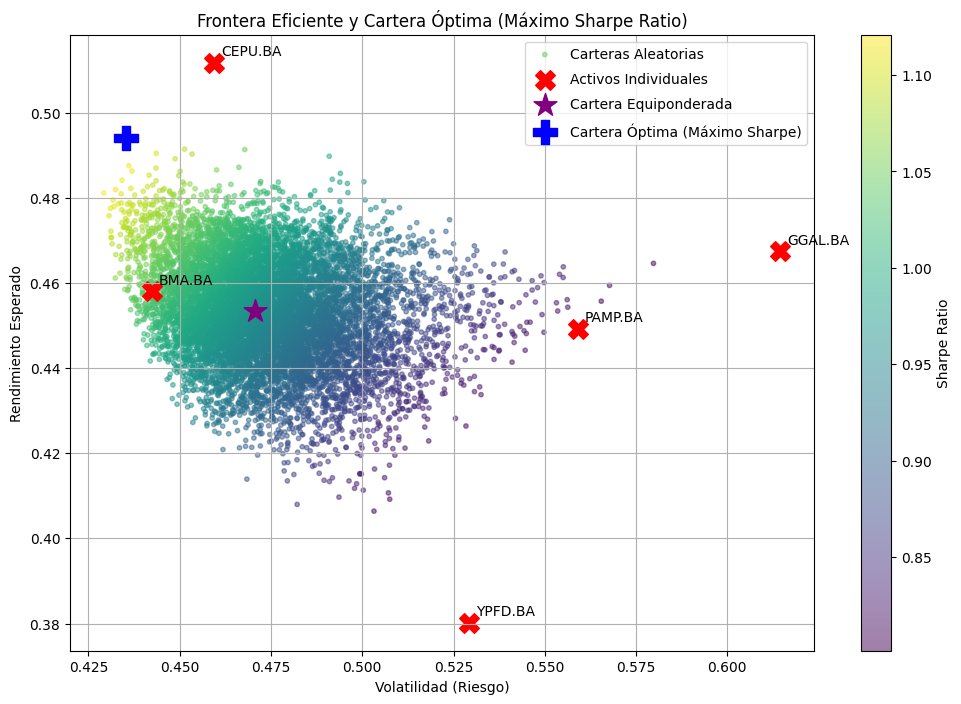

In [ ]:
plt.figure(figsize=(12, 8))

# Plotear la nube de puntos de la simulación de Monte Carlo (todas las carteras aleatorias)
plt.scatter(
    all_portfolio_volatilities, all_portfolio_returns,
    c=all_portfolio_sharpe_ratios, cmap='viridis',
    marker='o', s=10, alpha=0.5, label='Carteras Aleatorias'
)
plt.colorbar(label='Sharpe Ratio')

# Plotear los activos individuales
asset_volatilities = np.sqrt(np.diag(cov_matrix))
asset_returns = expected_returns
plt.scatter(asset_volatilities, asset_returns, marker='X', color='red', s=200, label='Activos Individuales')
for i, txt in enumerate(assets):
    plt.annotate(txt, (asset_volatilities[i], asset_returns[i]), xytext=(5, 5), textcoords='offset points')

# Plotear la cartera equiponderada
plt.scatter(
    equally_weighted_portfolio_volatility, equally_weighted_portfolio_return,
    marker='*', color='purple', s=300, label='Cartera Equiponderada'
)

# Plotear la cartera óptima de Máximo Ratio de Sharpe
plt.scatter(
    optimal_portfolio_volatility, optimal_portfolio_return,
    marker='P', color='blue', s=300, label='Cartera Óptima (Máximo Sharpe)'
)

plt.title('Frontera Eficiente y Cartera Óptima (Máximo Sharpe Ratio)')
plt.xlabel('Volatilidad (Riesgo)')
plt.ylabel('Rendimiento Esperado')
plt.grid(True)
plt.legend(labelspacing=0.8)
plt.show()